# 1. Exploration des données (EDA)
## Projet B3 Deep Learning — Détection de pneumonie

---

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)

DATA_DIR = Path('../data/chest_xray')
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)
print('Configuration OK')

Configuration OK


## 1.1 Téléchargement du dataset

```bash
# Via UV + Kaggle API
uv run kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
unzip chest-xray-pneumonia.zip -d ../data/
```

In [2]:
# Verification de la structure
if DATA_DIR.exists():
    for split in ["train", "val", "test"]:
        split_path = DATA_DIR / split
        if split_path.exists():
            classes = [d.name for d in split_path.iterdir() if d.is_dir()]
            print(f"{split}/ -> {classes}")
else:
    print(f"Attention : dataset non trouve a {DATA_DIR}")

train/ -> ['PNEUMONIA', 'NORMAL']
val/ -> ['PNEUMONIA', 'NORMAL']
test/ -> ['PNEUMONIA', 'NORMAL']


## 1.2 Statistiques descriptives

In [3]:
def count_images(data_dir):
    stats = {}
    for split in ["train", "val", "test"]:
        split_path = data_dir / split
        if not split_path.exists(): continue
        stats[split] = {}
        for cls in ["NORMAL", "PNEUMONIA"]:
            cls_path = split_path / cls
            if cls_path.exists():
                imgs = list(cls_path.glob("*.jpeg")) + list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
                stats[split][cls] = len(imgs)
            else:
                stats[split][cls] = 0
    return stats

stats = count_images(DATA_DIR)
df_stats = pd.DataFrame(stats).T
df_stats["Total"] = df_stats.sum(axis=1)
df_stats["Ratio (P/N)"] = (df_stats["PNEUMONIA"] / df_stats["NORMAL"]).round(2)
print("\nRepartition des images :")
print(df_stats.to_string())
print(f"\nTotal global : {df_stats['Total'].sum()} images")


Repartition des images :
       NORMAL  PNEUMONIA  Total  Ratio (P/N)
train    1341       3875   5216         2.89
val         8          8     16         1.00
test      234        390    624         1.67

Total global : 5856 images


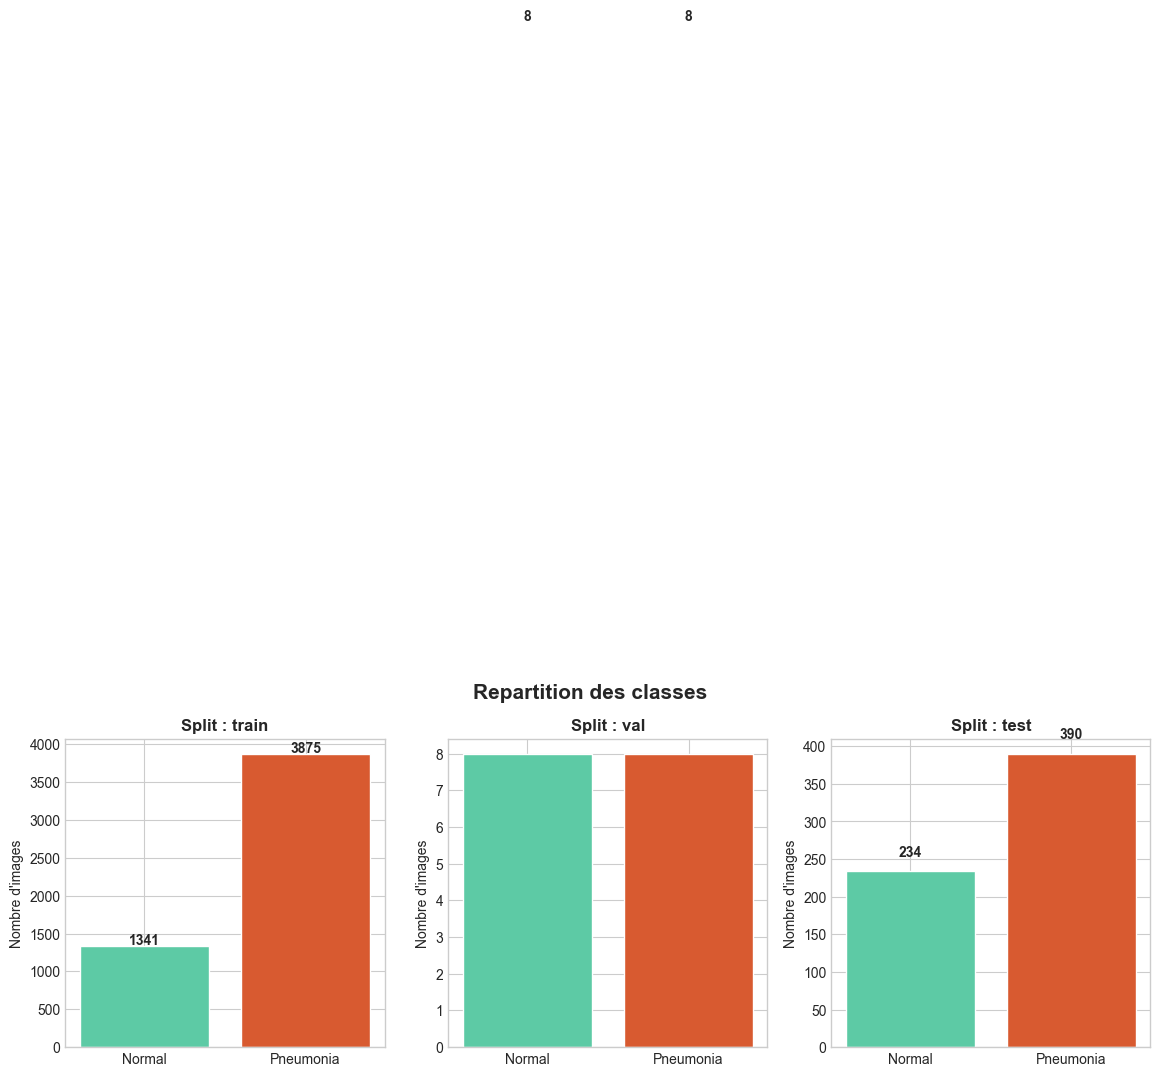

Attention : le dataset est DESEQUILIBRE (~2.9:1 en faveur de Pneumonia)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["#5DCAA5", "#D85A30"]
for idx, split in enumerate(["train", "val", "test"]):
    if split in stats:
        values = [stats[split].get("NORMAL", 0), stats[split].get("PNEUMONIA", 0)]
        bars = axes[idx].bar(["Normal", "Pneumonia"], values, color=colors, edgecolor="white")
        axes[idx].set_title(f"Split : {split}", fontweight="bold")
        axes[idx].set_ylabel("Nombre d'images")
        for bar, val in zip(bars, values):
            axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height()+20, str(val), ha="center", fontweight="bold")

plt.suptitle("Repartition des classes", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Attention : le dataset est DESEQUILIBRE (~2.9:1 en faveur de Pneumonia)")

## 1.3 Dimensions des images

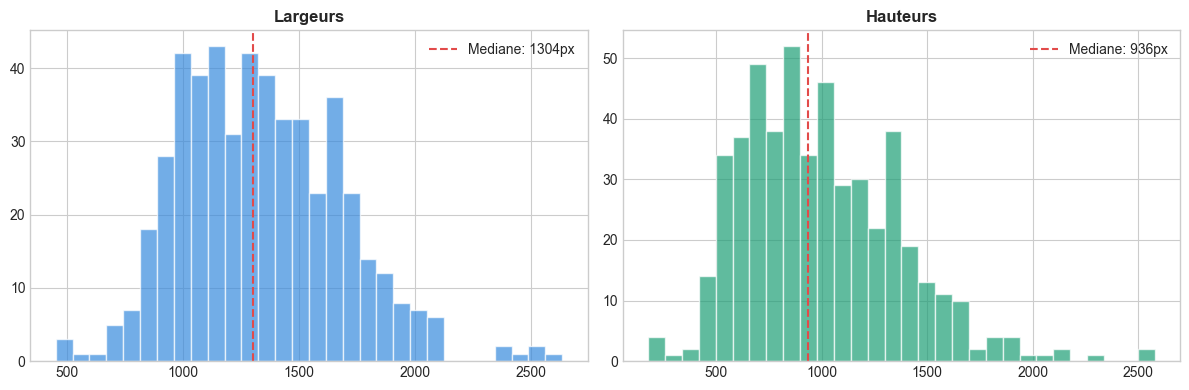


Statistiques des dimensions :
         min   max  moyenne  mediane
Largeur  453  2633     1334     1304
Hauteur  178  2578      994      936

-> Redimensionnement a 224x224 pour le CNN


In [5]:
def analyze_dimensions(data_dir, split="train", n_samples=500):
    widths, heights = [], []
    all_imgs = []
    for cls in ["NORMAL", "PNEUMONIA"]:
        cls_path = data_dir / split / cls
        if cls_path.exists():
            all_imgs.extend(list(cls_path.glob("*.jpeg")) + list(cls_path.glob("*.jpg")))
    np.random.shuffle(all_imgs)
    for img_path in all_imgs[:n_samples]:
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w); heights.append(h)
        except Exception: continue
    return widths, heights

widths, heights = analyze_dimensions(DATA_DIR)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color="#378ADD", alpha=0.7, edgecolor="white")
axes[0].set_title("Largeurs", fontweight="bold")
axes[0].axvline(np.median(widths), color="#E24B4A", linestyle="--", label=f"Mediane: {int(np.median(widths))}px")
axes[0].legend()
axes[1].hist(heights, bins=30, color="#1D9E75", alpha=0.7, edgecolor="white")
axes[1].set_title("Hauteurs", fontweight="bold")
axes[1].axvline(np.median(heights), color="#E24B4A", linestyle="--", label=f"Mediane: {int(np.median(heights))}px")
axes[1].legend()
plt.tight_layout()
plt.savefig("../outputs/figures/image_dimensions.png", dpi=150, bbox_inches="tight")
plt.show()

# Tableau recapitulatif des dimensions
dim_stats = {
    "Largeur": {
        "min": int(np.min(widths)), "max": int(np.max(widths)),
        "moyenne": int(np.mean(widths)), "mediane": int(np.median(widths)),
    },
    "Hauteur": {
        "min": int(np.min(heights)), "max": int(np.max(heights)),
        "moyenne": int(np.mean(heights)), "mediane": int(np.median(heights)),
    },
}
print("\nStatistiques des dimensions :")
df_dim = pd.DataFrame(dim_stats).T
print(df_dim.to_string())
print(f"\n-> Redimensionnement a 224x224 pour le CNN")

In [6]:
# Formats d'images
format_counter = Counter()
for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        cls_path = DATA_DIR / split / cls
        if not cls_path.exists(): continue
        for img_path in cls_path.iterdir():
            ext = img_path.suffix.lower()
            if ext in [".jpeg", ".jpg", ".png"]:
                format_counter[ext] += 1

total_imgs = sum(format_counter.values())
print("Formats d'images :")
for fmt, count in format_counter.most_common():
    print(f"   {fmt}: {count} ({count/total_imgs*100:.1f}%)")

Formats d'images :
   .jpeg: 5856 (100.0%)


## 1.4 Exemples de radiographies

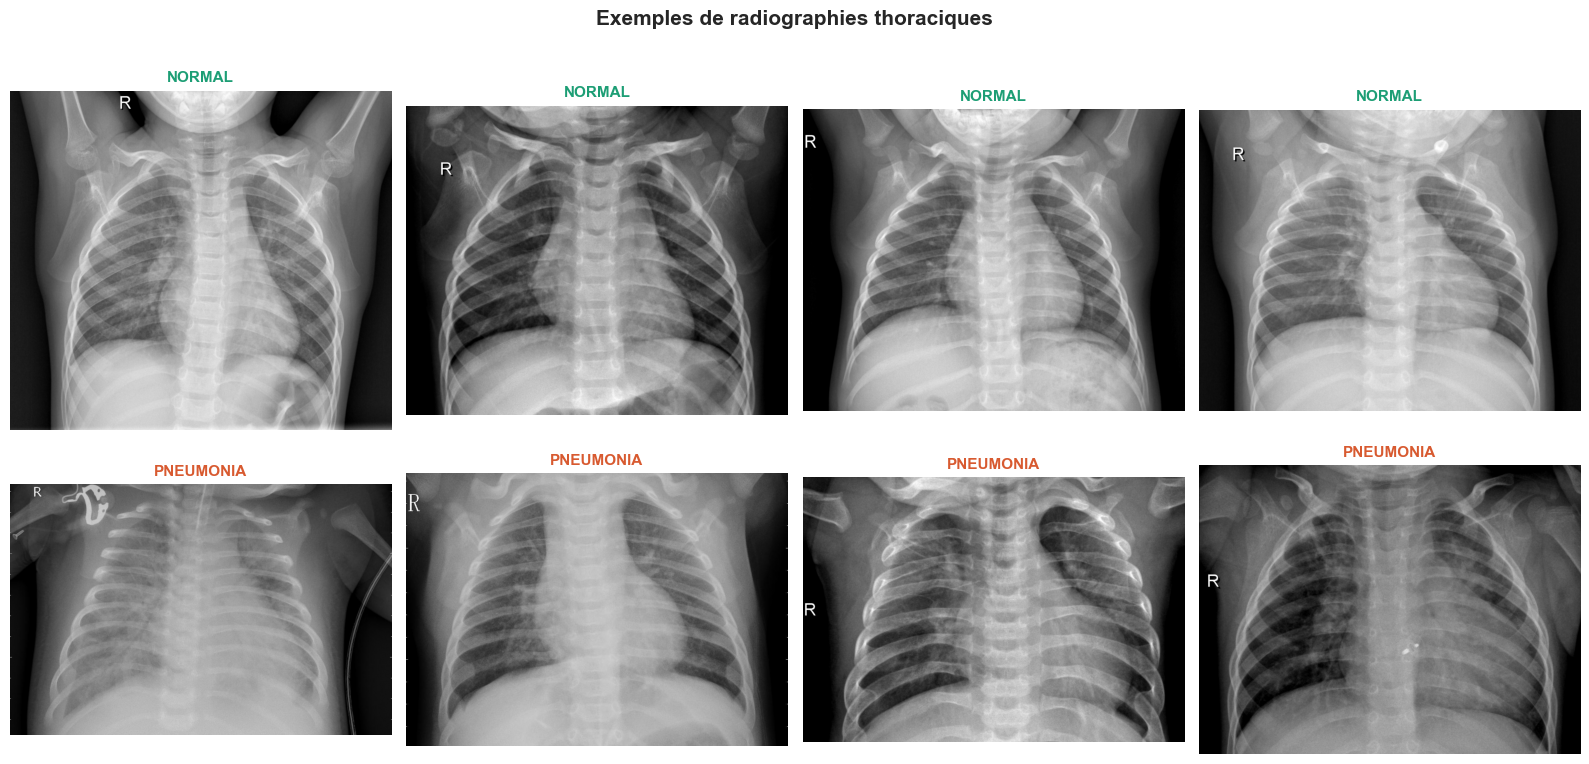

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, cls in enumerate(["NORMAL", "PNEUMONIA"]):
    cls_path = DATA_DIR / "train" / cls
    imgs = sorted(cls_path.glob("*.jpeg"))[:4]
    for col, img_path in enumerate(imgs):
        img = Image.open(img_path).convert("L")
        axes[row, col].imshow(img, cmap="gray")
        color = "#1D9E75" if cls == "NORMAL" else "#D85A30"
        axes[row, col].set_title(cls, fontsize=11, color=color, fontweight="bold")
        axes[row, col].axis("off")
plt.suptitle("Exemples de radiographies thoraciques", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/sample_images.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.5 Détection d'images corrompues

In [8]:
corrupted, total = [], 0
for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        cls_path = DATA_DIR / split / cls
        if not cls_path.exists(): continue
        for img_path in cls_path.iterdir():
            if img_path.suffix.lower() in [".jpeg", ".jpg", ".png"]:
                total += 1
                try:
                    with Image.open(img_path) as img: img.verify()
                except Exception as e:
                    corrupted.append((str(img_path), str(e)))

print(f"Verification de {total} images...")
print("Aucune corrompue" if not corrupted else f"Attention : {len(corrupted)} corrompues")

Verification de 5856 images...
Aucune corrompue


## 1.6 Verification du data leakage

On verifie s'il y a des doublons ou des images du meme patient entre les splits train/test, ce qui fausserait l'evaluation.

In [9]:
# Extraire les noms de fichiers par split
split_files = {}
split_patients = {}
for split in ["train", "val", "test"]:
    files = set()
    patients = set()
    for cls in ["NORMAL", "PNEUMONIA"]:
        cls_path = DATA_DIR / split / cls
        if not cls_path.exists(): continue
        for img_path in cls_path.iterdir():
            if img_path.suffix.lower() in [".jpeg", ".jpg", ".png"]:
                files.add(img_path.name)
                # Extraire le patient ID (ex: "person1_bacteria_1.jpeg" -> "person1")
                match = re.match(r"(person\d+)", img_path.name)
                if match:
                    patients.add(match.group(1))
    split_files[split] = files
    split_patients[split] = patients

# 1. Doublons exacts (memes noms de fichiers)
print("=== Verification des doublons ===")
for s1, s2 in [("train", "test"), ("train", "val"), ("val", "test")]:
    common = split_files.get(s1, set()) & split_files.get(s2, set())
    print(f"   Fichiers communs {s1}/{s2}: {len(common)}")

# 2. Patients partages entre splits
print("\n=== Patients partages entre splits ===")
shared_patients = {}
for s1, s2 in [("train", "test"), ("train", "val"), ("val", "test")]:
    shared = split_patients.get(s1, set()) & split_patients.get(s2, set())
    shared_patients[f"{s1}_{s2}"] = len(shared)
    print(f"   Patients communs {s1}/{s2}: {len(shared)}")
    if shared and len(shared) <= 5:
        print(f"      -> {sorted(shared)}")

print("\n=== Resume ===")
total_shared = shared_patients.get("train_test", 0)
if total_shared > 0:
    print(f"ATTENTION : {total_shared} patients sont presents dans train ET test !")
    print("Risque de data leakage -- les metriques test pourraient etre optimistes.")
else:
    print("Aucun patient partage entre train et test.")

=== Verification des doublons ===
   Fichiers communs train/test: 0
   Fichiers communs train/val: 0
   Fichiers communs val/test: 0

=== Patients partages entre splits ===
   Patients communs train/test: 170
   Patients communs train/val: 0
   Patients communs val/test: 0

=== Resume ===
ATTENTION : 170 patients sont presents dans train ET test !
Risque de data leakage -- les metriques test pourraient etre optimistes.


## 1.7 Constat sur le set de validation

In [10]:
if "val" in stats:
    print(f"Val set original : NORMAL={stats['val'].get('NORMAL',0)}, PNEUMONIA={stats['val'].get('PNEUMONIA',0)}")
    print("Attention : trop peu ! On re-splittera le train set (85/15) dans le notebook 02.")

Val set original : NORMAL=8, PNEUMONIA=8
Attention : trop peu ! On re-splittera le train set (85/15) dans le notebook 02.


## 1.8 Discussion sur la qualite des labels

**Source des donnees** : radiographies thoraciques du Guangzhou Women and Children's Medical Center (Chine), patients pediatriques ages de 1 a 5 ans.

**Processus de labelling** :
- Les labels ont ete attribues par deux medecins experts en radiologie
- Un troisieme medecin expert a valide les diagnostics pour assurer la coherence

**Limites identifiees** :
1. **Centre unique** : toutes les images proviennent du meme hopital, ce qui limite la diversite des equipements et protocoles d'acquisition
2. **Population pediatrique uniquement** : les radiographies d'enfants ont des caracteristiques differentes de celles des adultes (taille du thorax, ratio cardiaque, etc.)
3. **Biais geographique** : un seul centre en Chine, pas de representation multi-ethnique ou multi-regionale
4. **Impact sur la generalisabilite** : un modele entraine sur ces donnees pourrait mal generaliser sur des radiographies d'adultes, d'autres centres, ou d'autres equipements

## 1.9 Export des resultats EDA

In [11]:
eda_summary = {
    "dataset": {
        split: {
            cls: stats.get(split, {}).get(cls, 0)
            for cls in ["NORMAL", "PNEUMONIA"]
        }
        for split in ["train", "val", "test"]
    },
    "ratios": {
        split: round(stats.get(split, {}).get("PNEUMONIA", 0) /
                      max(stats.get(split, {}).get("NORMAL", 1), 1), 2)
        for split in ["train", "val", "test"]
    },
    "total_images": int(df_stats["Total"].sum()),
    "dimensions": dim_stats,
    "formats": {fmt: count for fmt, count in format_counter.most_common()},
    "corrupted_images": len(corrupted),
    "data_leakage": {
        "duplicate_filenames_train_test": len(split_files.get("train", set()) & split_files.get("test", set())),
        "shared_patients_train_test": shared_patients.get("train_test", 0),
        "shared_patients_train_val": shared_patients.get("train_val", 0),
    },
}

with open("../outputs/eda_summary.json", "w", encoding="utf-8") as f:
    json.dump(eda_summary, f, indent=4, ensure_ascii=False)
print("EDA exportee vers outputs/eda_summary.json")

EDA exportee vers outputs/eda_summary.json


## Resume EDA

| Aspect | Observation | Action |
|--------|-------------|--------|
| Classes | Desequilibre ~2.9:1 | `WeightedRandomSampler` + `pos_weight` |
| Dimensions | Variables (1000-2000px) | Resize 224x224 |
| Qualite | Pas de corruption | OK |
| Val set | Trop petit (8+8) | Re-split stratifie du train (85/15) |
| Format | JPEG grayscale | Conversion RGB 3 canaux |
| Data leakage | Patients potentiellement partages | A surveiller, K-fold en complement |
| Labels | 2 experts + validation par un 3e | Source unique (pediatrie, 1 centre) |

-> **Suite** : `02_training_cnn.ipynb`